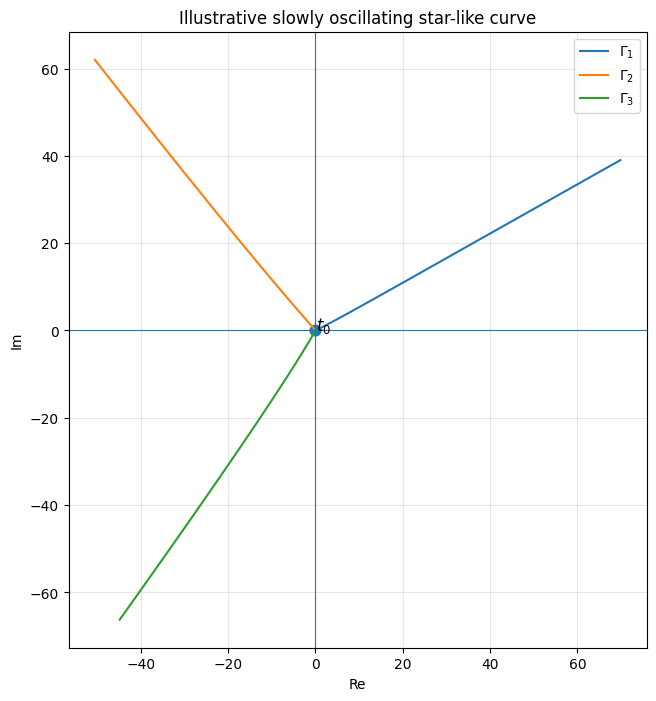

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def theta_factory(alpha, eps=0.22, phase=0.0):
    """
    Ejemplo suave e ilustrativo de función angular:
        theta(r) = alpha + eps * sin(log(log(e^2 + r)) + phase)

    No pretende verificar automáticamente todas las hipótesis del paper;
    sirve para visualizar curvas star-like con oscilación lenta.
    """
    def theta(r):
        return alpha + eps * np.sin(np.log(np.log(np.e**2 + r)) + phase)
    return theta


def gamma_branch(r, theta, t0=0+0j):
    """
    Parametrización:
        tau = t0 + r * exp(i theta(r))
    """
    th = theta(r)
    tau = t0 + r * np.exp(1j * th)
    return tau


def plot_slowly_oscillating_star_like_curve(
    t0=0+0j,
    r_min=1e-3,
    r_max=80,
    num_points=4000,
):
    # Malla radial positiva
    r = np.geomspace(r_min, r_max, num_points)

    # Ángulos base separados para conservar estructura star-like
    # Puedes mover eps si quieres más o menos oscilación.
    thetas = [
        theta_factory(alpha=0.35, eps=0.16, phase=0.0),
        theta_factory(alpha=2.15, eps=0.14, phase=0.8),
        theta_factory(alpha=4.10, eps=0.12, phase=1.5),
    ]

    plt.figure(figsize=(8, 8))

    for k, theta in enumerate(thetas, start=1):
        tau = gamma_branch(r, theta, t0=t0)
        plt.plot(tau.real, tau.imag, label=fr"$\Gamma_{k}$")

    # Punto t0
    plt.scatter([t0.real], [t0.imag], s=60, marker="o")
    plt.text(t0.real + 0.08, t0.imag + 0.08, r"$t_0$", fontsize=12)

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title("Illustrative slowly oscillating star-like curve")
    plt.xlabel("Re")
    plt.ylabel("Im")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


if __name__ == "__main__":
    plot_slowly_oscillating_star_like_curve()